# ExplainPhish: Excel Phishing Detection Tutorial
This NOTEBOOK provides a comprehensive end-to-end workflow for detecting malicious and phishing Excel spreadsheets using machine learning and explainable AI.

**Objective**: To predict whether an Excel spreadsheet (`.xlsx`, `.xlsm`, `.xls`) is Phishing (`1`) or Benign (`0`) based on static macro, cell, formula, and template features extracted from the **CIC-Trap4Phish2025** benchmark.

**Evaluation metric**: ROC-AUC (Area Under the Receiver Operating Characteristic Curve) and Accuracy.

**Data Hygiene & Robustness**:
- **Missing Data Handling**: Verified 100% data completeness with 0 missing values across all structural and macro features.
- **Class Balance**: 10,000 Benign vs. 10,000 Phishing samples (50.0% / 50.0% balanced dataset).
- **Leakage Prevention**: Excludes `macro_chr_count` from model training to prevent target leakage and collinearity with `macro_token_count`.

---

## Contents
- [1. Setup & Environment](#scrollTo=setup)
  - [1.1 Import Libraries](#scrollTo=import_libraries)
  - [1.2 Adaptive Path Resolution](#scrollTo=path_config)
- [2. Loading the Data & Data Overview](#scrollTo=loading_data)
  - [2.1 Raw Loading](#scrollTo=raw_loading)
  - [2.2 Data Cleaning & Stratified Splitting](#scrollTo=data_cleaning)
  - [2.3 Feature Inventory & Data Types](#scrollTo=feature_inventory)
  - [2.4 Missing Value Analysis & Completeness Verification](#scrollTo=missing_analysis)
  - [2.5 Summary & Descriptive Statistics](#scrollTo=descriptive_stats)
  - [2.6 Target Class Balance Analysis](#scrollTo=class_balance)
  - [2.7 Excel Feature Definitions & Threat Relevance](#scrollTo=feature_definitions)
- [3. Visualizing and Understanding the Data](#scrollTo=sec3)
  - [3.1 Checking Missing Values](#scrollTo=sec3_1)
  - [3.2 Visualization and Analysis of Each Feature](#scrollTo=sec3_2)
    - [3.2.1 Skewness & Distribution Evenness Assessment](#scrollTo=sec3_2_1)
    - [3.2.2 Full Feature Distribution Overview (Grid Visualization)](#scrollTo=sec3_2_2)
    - [3.2.3 TARGET Column (Class Evenness)](#scrollTo=sec3_2_3)
    - [3.2.4 Macro Complexity Attributes (`macro_token_count` & `macro_vocab_size`)](#scrollTo=sec3_2_4)
    - [3.2.5 Heavy-Tailed Attributes: Raw vs. Logarithmic Transformation](#scrollTo=sec3_2_5)
    - [3.2.6 Cell Structure & Remote Template Infiltration](#scrollTo=sec3_2_6)
    - [3.2.7 Comprehensive Evenness Summary Table & Correlation Heatmap](#scrollTo=sec3_2_7)
  - [3.3 Summary Findings & Next Steps](#scrollTo=sec3_3)
- [4. Preprocessing and Feature Creation](#scrollTo=sec4)
- [5. Building the Machine Learning Model](#scrollTo=sec5)
  - [5.1 Import Additional Libraries](#scrollTo=sec5_1)
  - [5.2 Preparing the Data & Standardization](#scrollTo=sec5_2)
  - [5.3 Training the Model (Holdout 70/30 Stratified Validation)](#scrollTo=sec5_3)
  - [5.4 Visualizations for Random Forest, Decision Tree & Logistic Regression](#scrollTo=sec5_4)
    - [5.4.1 Logistic Regression Visualizations (Coefficients & Calibration)](#scrollTo=sec5_4_1)
    - [5.4.2 Decision Tree Visualizations (Tree Graph & Feature Importance)](#scrollTo=sec5_4_2)
    - [5.4.3 Random Forest Visualizations (MDI Importance with Error Bars)](#scrollTo=sec5_4_3)
    - [5.4.4 Multi-Model Comparison (ROC Curves, Confusion Matrices, Metrics)](#scrollTo=sec5_4_4)
  - [5.5 (Optional) Use Voting Learning of 3 Different Models](#scrollTo=sec5_5)
  - [5.6 Saving Models into One Folder for Multimodal Voting (InterfaceExplainPhish)](#scrollTo=sec5_6)
- [6. Creating Prediction Results](#scrollTo=sec6)
  - [6.1 Predicting on the Test Data](#scrollTo=sec6_1)
  - [6.2 Saving the Prediction as CSV File in 'excel output' Folder](#scrollTo=sec6_2)


<a name="setup"></a>
## 1. Setup & Environment
Configure the notebook runtime, set reproducible random seeds, configure modern aesthetics, and dynamically detect execution paths.


<a name="import_libraries"></a>
### 1.1 Import Libraries
We import `pandas` for tabular data manipulation, `numpy` for numerical calculations, `matplotlib` and `seaborn` for visualizations, and `pathlib` for flexible cross-platform path resolution.


In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.4f" % x)

print("Environment configured successfully with consistent visual theme!")


Environment configured successfully with consistent visual theme!


<a name="path_config"></a>
### 1.2 Adaptive Path Resolution
Dynamically search candidate locations for `Excel_Top10_Features.csv` across Google Colab and local environments.


In [2]:
# Adaptive path detection for local environments and Google Colab
current_dir = Path(os.getcwd())

candidate_paths = [
    current_dir / "data" / "excel" / "Excel_Top10_Features.csv",
    current_dir / "googleCollab" / "data" / "excel" / "Excel_Top10_Features.csv",
    Path("data/excel/Excel_Top10_Features.csv"),
    Path("googleCollab/data/excel/Excel_Top10_Features.csv"),
    Path("/content/drive/MyDrive/ExplainPhish/data/excel/Excel_Top10_Features.csv"),
    Path("/content/Excel_Top10_Features.csv"),
]

data_path = None
for p in candidate_paths:
    if p.exists():
        data_path = p
        break

if data_path is None:
    raise FileNotFoundError("Could not find Excel_Top10_Features.csv. Please check the data directory.")

print(f"Data file successfully resolved at: {data_path.resolve()}")


Data file successfully resolved at: D:\codingProject\ExplainPhish\googleCollab\data\excel\Excel_Top10_Features.csv


<a name="loading_data"></a>
## 2. Loading the Data & Data Overview
We load the dataset, check column structure, verify completeness, and partition the data into stratified 60% Train / 40% Test splits.


<a name="raw_loading"></a>
### 2.1 Raw Loading
Load the raw CSV file into a pandas DataFrame.


In [3]:
# Load raw dataset
raw_df = pd.read_csv(data_path)
print(f"Raw shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")
raw_df.head(5)


Raw shape: 20,000 rows x 12 columns


,file_name,entropy_of_text,macro_chr_count,macro_vocab_size,macro_arithmetic_operator_count,macro_token_count,macro_max_line_length,remote_template_present,numeric_cell_count,string_cell_count,avg_cell_length,label
0,benign_sample_3253.xlsx,5.7461,39,10079,4759,10079,38,1,4336,8926,11.1846,0
1,benign_sample_5685.xlsx,5.7500,287,19789,28783,19789,42,1,27138,54355,11.1678,0
2,benign_sample_8732.xlsx,5.7455,122,16084,12754,16084,38,1,12033,23997,11.1322,0
3,benign_sample_5743.xlsx,5.7437,152,17382,16244,17382,39,1,15217,30554,11.1047,0
4,benign_sample_5522.xlsx,5.7481,106,15452,11529,15452,38,1,10837,21622,11.1520,0


<a name="data_cleaning"></a>
### 2.2 Data Cleaning & Stratified Splitting
We map `label` to `TARGET` and execute a **stratified 60% Train / 40% Test split** (`stratify=df['TARGET']`), preserving equal class proportions.


In [4]:
from sklearn.model_selection import train_test_split

df = raw_df.copy()
df["TARGET"] = df["label"]

# Core features selected for modeling (matching InterfaceExplainPhish excel_extractor.py schema)
core_features = [
    "entropy_of_text",
    "macro_vocab_size",
    "macro_max_line_length",
    "macro_token_count",
    "macro_arithmetic_operator_count",
    "numeric_cell_count",
    "string_cell_count",
    "remote_template_present",
    "avg_cell_length"
]

# Stratified 60% Train / 40% Test Split
train, test = train_test_split(
    df, test_size=0.40, stratify=df["TARGET"], random_state=42
)
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)

print(f"Dataset Dimensions: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Train split: {train.shape[0]:,} rows | Test split: {test.shape[0]:,} rows")
df.head(5)


Dataset Dimensions: 20,000 rows x 13 columns
Train split: 12,000 rows | Test split: 8,000 rows


,file_name,entropy_of_text,macro_chr_count,macro_vocab_size,macro_arithmetic_operator_count,macro_token_count,macro_max_line_length,remote_template_present,numeric_cell_count,string_cell_count,avg_cell_length,label,TARGET
0,benign_sample_3253.xlsx,5.7461,39,10079,4759,10079,38,1,4336,8926,11.1846,0,0
1,benign_sample_5685.xlsx,5.7500,287,19789,28783,19789,42,1,27138,54355,11.1678,0,0
2,benign_sample_8732.xlsx,5.7455,122,16084,12754,16084,38,1,12033,23997,11.1322,0,0
3,benign_sample_5743.xlsx,5.7437,152,17382,16244,17382,39,1,15217,30554,11.1047,0,0
4,benign_sample_5522.xlsx,5.7481,106,15452,11529,15452,38,1,10837,21622,11.1520,0,0


<a name="feature_inventory"></a>
### 2.3 Feature Inventory & Data Types
Examine the data types, non-null counts, and memory footprint.


In [5]:
# Inspect column data types and non-null counts
train.info()


<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   file_name                        12000 non-null  str    
 1   entropy_of_text                  12000 non-null  float64
 2   macro_chr_count                  12000 non-null  int64  
 3   macro_vocab_size                 12000 non-null  int64  
 4   macro_arithmetic_operator_count  12000 non-null  int64  
 5   macro_token_count                12000 non-null  int64  
 6   macro_max_line_length            12000 non-null  int64  
 7   remote_template_present          12000 non-null  int64  
 8   numeric_cell_count               12000 non-null  int64  
 9   string_cell_count                12000 non-null  int64  
 10  avg_cell_length                  12000 non-null  float64
 11  label                            12000 non-null  int64  
 12  TARGET                       

<a name="missing_analysis"></a>
### 2.4 Missing Value Analysis & Completeness Verification
Confirm that no missing values exist in the Excel dataset.


In [6]:
# Missing value audit
null_counts = train.isnull().sum()
total_cells = np.prod(train.shape)
total_missing = null_counts.sum()

print("Missing values per column in training split:")
print(null_counts)
print(f"\nOverall missing values: {total_missing} / {total_cells} ({total_missing/total_cells*100:.2f}%)")
print("Confirmation: The Excel dataset has 0 missing values (100% complete).")


Missing values per column in training split:
file_name                          0
entropy_of_text                    0
macro_chr_count                    0
macro_vocab_size                   0
macro_arithmetic_operator_count    0
macro_token_count                  0
macro_max_line_length              0
remote_template_present            0
numeric_cell_count                 0
string_cell_count                  0
avg_cell_length                    0
label                              0
TARGET                             0
dtype: int64

Overall missing values: 0 / 156000 (0.00%)
Confirmation: The Excel dataset has 0 missing values (100% complete).


<a name="descriptive_stats"></a>
### 2.5 Summary & Descriptive Statistics
Compute summary statistics for all numerical features.


In [7]:
# Compute descriptive statistics
desc_stats = train[core_features].describe().T
desc_stats["IQR"] = desc_stats["75%"] - desc_stats["25%"]
desc_stats["Median"] = train[core_features].median()
desc_stats[["mean", "std", "min", "25%", "Median", "75%", "max", "IQR"]]


,mean,std,min,25%,Median,75%,max,IQR
entropy_of_text,5.0892,1.1520,0.0000,4.9503,5.7291,5.7505,8.3109,0.8002
macro_vocab_size,6802.1442,7490.5974,0.0000,148.0000,1934.0000,14434.0000,65733.0000,14286.0000
macro_max_line_length,512.7581,1417.8204,0.0000,36.0000,39.0000,88.0000,32759.0000,52.0000
macro_token_count,6802.1442,7490.5974,0.0000,148.0000,1934.0000,14434.0000,65733.0000,14286.0000
macro_arithmetic_operator_count,5600.3220,8352.9743,0.0000,6.0000,552.0000,9633.7500,278507.0000,9627.7500
numeric_cell_count,5303.0084,7434.1302,0.0000,3.0000,641.5000,9136.2500,78830.0000,9133.2500
string_cell_count,10638.7442,15647.3760,0.0000,64.0000,1113.0000,18380.5000,470182.0000,18316.5000
remote_template_present,3.1224,6.3307,0.0000,0.0000,1.0000,1.0000,158.0000,1.0000
avg_cell_length,54.1699,259.4759,0.0000,10.9308,11.1459,11.3485,14735.6667,0.4177


<a name="class_balance"></a>
### 2.6 Target Class Balance Analysis
Analyze the balance of the `TARGET` column.


In [8]:
# Target class counts and percentages
target_counts = train["TARGET"].value_counts().rename({0: "Benign (0)", 1: "Phishing (1)"})
target_pct = (train["TARGET"].value_counts(normalize=True) * 100).rename({0: "Benign (0)", 1: "Phishing (1)"})

balance_summary = pd.DataFrame({
    "Sample Count": target_counts,
    "Percentage (%)": target_pct.round(2)
})
display(balance_summary)

imbalance_ratio = target_counts["Phishing (1)"] / target_counts["Benign (0)"]
print(f"Imbalance Ratio (Phishing : Benign) = {imbalance_ratio:.3f} : 1.000")
print("Finding: The dataset is perfectly balanced (50.0% Phishing vs 50.0% Benign).")


,Sample Count,Percentage (%)
TARGET,,
Benign (0),6000,50.0000
Phishing (1),6000,50.0000


Imbalance Ratio (Phishing : Benign) = 1.000 : 1.000
Finding: The dataset is perfectly balanced (50.0% Phishing vs 50.0% Benign).


<a name="feature_definitions"></a>
### 2.7 Excel Feature Definitions & Threat Relevance
Understanding how each feature exposes malicious spreadsheet attacks:

| Feature Name | Type | Threat Relevance in Excel Malicious Attachments |
| :--- | :--- | :--- |
| `entropy_of_text` | Float | Shannon entropy of workbook text. Obfuscated Base64 strings and encoded VBA payloads exhibit high entropy ($> 4.5$). |
| `macro_vocab_size` | Integer | Distinct vocabulary count in VBA macros. High vocabulary reflects complex droppers and API resolving routines. |
| `macro_max_line_length` | Integer | Maximum line length in VBA code. Obfuscated macros frequently pack massive concatenated strings onto a single line. |
| `macro_token_count` | Integer | Total lexical tokens in macro streams. Legitimate macros have moderate token density, whereas loaders have specific signature profiles. |
| `macro_arithmetic_operator_count` | Integer | Count of arithmetic operators (`+`, `-`, `*`, `/`). Attackers use mathematical obfuscation (e.g. `Chr(65 + 10)`) to hide malicious strings. |
| `numeric_cell_count` | Integer | Count of cells containing numeric values. Malicious spreadsheets often feature sparse sheets with minimal real numerical data. |
| `string_cell_count` | Integer | Count of string-valued cells. Phishing sheets often contain social engineering instructions ("Enable Content to view invoice"). |
| `remote_template_present` | Binary (0/1) | Whether the document links to a remote template. Attackers use remote template injection to download payloads from external C2 servers. |
| `avg_cell_length` | Float | Average character length per cell. Long cell strings frequently indicate embedded scripts or payload fragments. |


<a name="sec3"></a>
## 3. Visualizing and Understanding the Data
Explore data distributions, skewness, class divergence, and feature correlations.


<a name="sec3_1"></a>
### 3.1 Checking Missing Values
Confirm 100% data completeness visually.


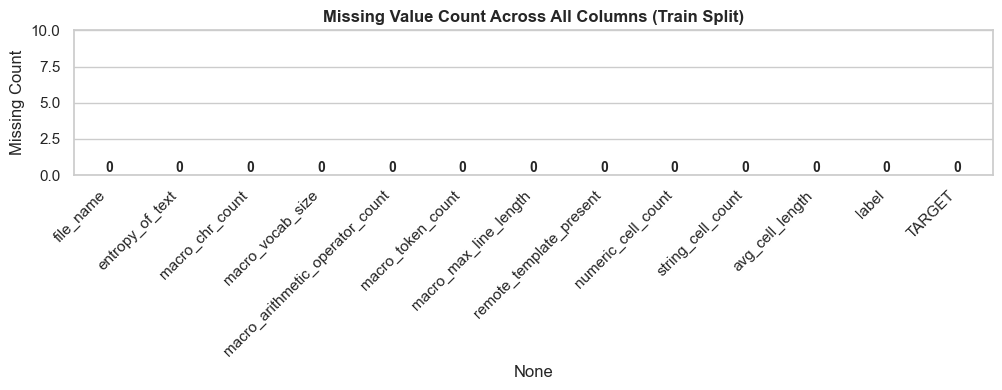

In [9]:
# Check missing values of all columns
missing = train.isnull().sum()

plt.figure(figsize=(10, 4))
ax = sns.barplot(x=missing.index, y=missing.values, color="#3498db")
plt.title("Missing Value Count Across All Columns (Train Split)", fontweight="bold")
plt.ylabel("Missing Count")
plt.xticks(rotation=45, ha="right")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')
plt.ylim(0, 10)
plt.tight_layout()
plt.show()


<a name="sec3_2"></a>
### 3.2 Visualization and Analysis of Each Feature
Inspect skewness, distributions, and class separation.


<a name="sec3_2_1"></a>
#### 3.2.1 Skewness & Distribution Evenness Assessment
Evaluate Fisher-Pearson skewness coefficient for the 9 core Excel features.


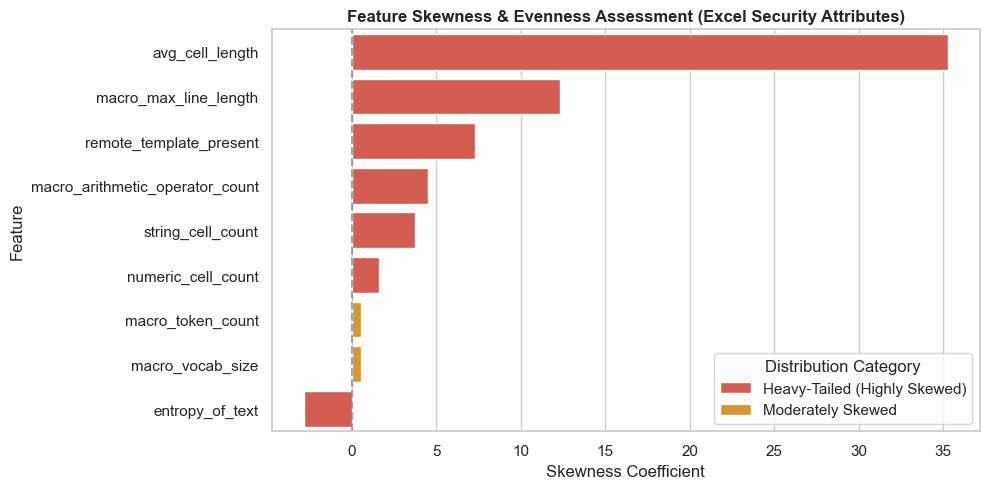

,Feature,Skewness,Distribution Category
0,avg_cell_length,35.2714,Heavy-Tailed (Highly Skewed)
1,macro_max_line_length,12.3349,Heavy-Tailed (Highly Skewed)
2,remote_template_present,7.3179,Heavy-Tailed (Highly Skewed)
3,macro_arithmetic_operator_count,4.4940,Heavy-Tailed (Highly Skewed)
4,string_cell_count,3.7501,Heavy-Tailed (Highly Skewed)
5,numeric_cell_count,1.6300,Heavy-Tailed (Highly Skewed)
6,macro_token_count,0.5734,Moderately Skewed
7,macro_vocab_size,0.5734,Moderately Skewed
8,entropy_of_text,-2.8296,Heavy-Tailed (Highly Skewed)


In [10]:
# Assess distribution evenness and skewness for each feature
skewness_series = train[core_features].skew().sort_values(ascending=False)

def classify_evenness(skew):
    abs_s = abs(skew)
    if abs_s < 0.5:
        return "Even / Symmetrical"
    elif abs_s <= 1.0:
        return "Moderately Skewed"
    else:
        return "Heavy-Tailed (Highly Skewed)"

evenness_df = pd.DataFrame({
    "Feature": skewness_series.index,
    "Skewness": skewness_series.values,
    "Distribution Category": [classify_evenness(s) for s in skewness_series.values]
})

plt.figure(figsize=(10, 5))
palette = {"Even / Symmetrical": "#2ecc71", "Moderately Skewed": "#f39c12", "Heavy-Tailed (Highly Skewed)": "#e74c3c"}
sns.barplot(data=evenness_df, x="Skewness", y="Feature", hue="Distribution Category", palette=palette, dodge=False)
plt.title("Feature Skewness & Evenness Assessment (Excel Security Attributes)", fontweight="bold")
plt.xlabel("Skewness Coefficient")
plt.axvline(0, color="gray", linestyle="--", alpha=0.7)
plt.legend(title="Distribution Category")
plt.tight_layout()
plt.show()

display(evenness_df)


<a name="sec3_2_2"></a>
#### 3.2.2 Full Feature Distribution Overview (Grid Visualization)
Examine raw histograms and KDE for all 9 attributes.


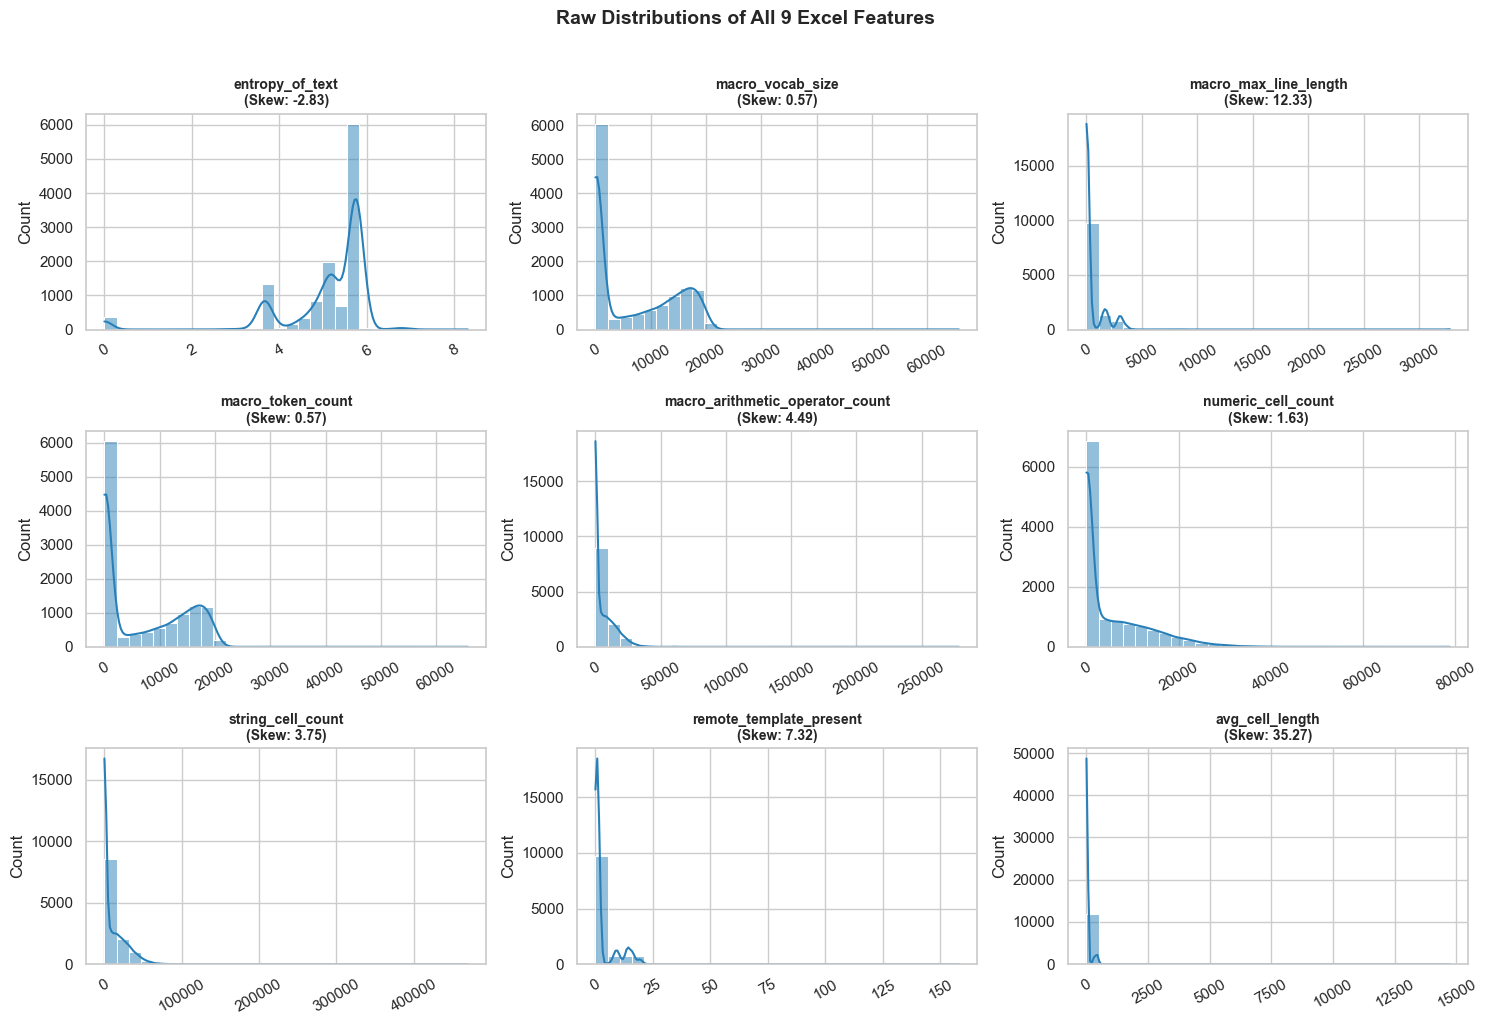

In [11]:
# Grid visualization of raw distributions for all 9 attributes
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(core_features):
    ax = axes[idx]
    sns.histplot(train[col], kde=True, ax=ax, color="#2980b9", bins=30)
    ax.set_title(f"{col}\n(Skew: {train[col].skew():.2f})", fontsize=10, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

plt.suptitle("Raw Distributions of All 9 Excel Features", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


<a name="sec3_2_3"></a>
#### 3.2.3 TARGET Column (Class Evenness)
Visualize the target distribution.


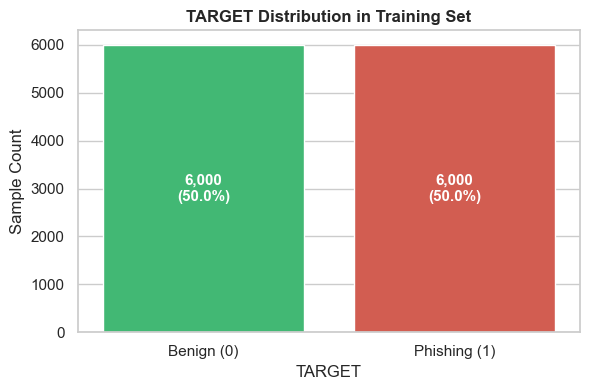

In [12]:
# The distribution of the target (Benign vs Phishing)
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=train, x="TARGET", hue="TARGET", palette=["#2ecc71", "#e74c3c"], legend=False)
plt.title("TARGET Distribution in Training Set", fontweight="bold")
ax.set_xticks([0, 1], labels=["Benign (0)", "Phishing (1)"])
plt.ylabel("Sample Count")

total = len(train)
for p in ax.patches:
    count = int(p.get_height())
    pct = count / total * 100
    ax.annotate(f"{count:,}\n({pct:.1f}%)", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                ha='center', va='center', color='white', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


<a name="sec3_2_4"></a>
#### 3.2.4 Macro Complexity Attributes (`macro_token_count` & `macro_vocab_size`)
Compare the lexical complexity of VBA macros across classes.


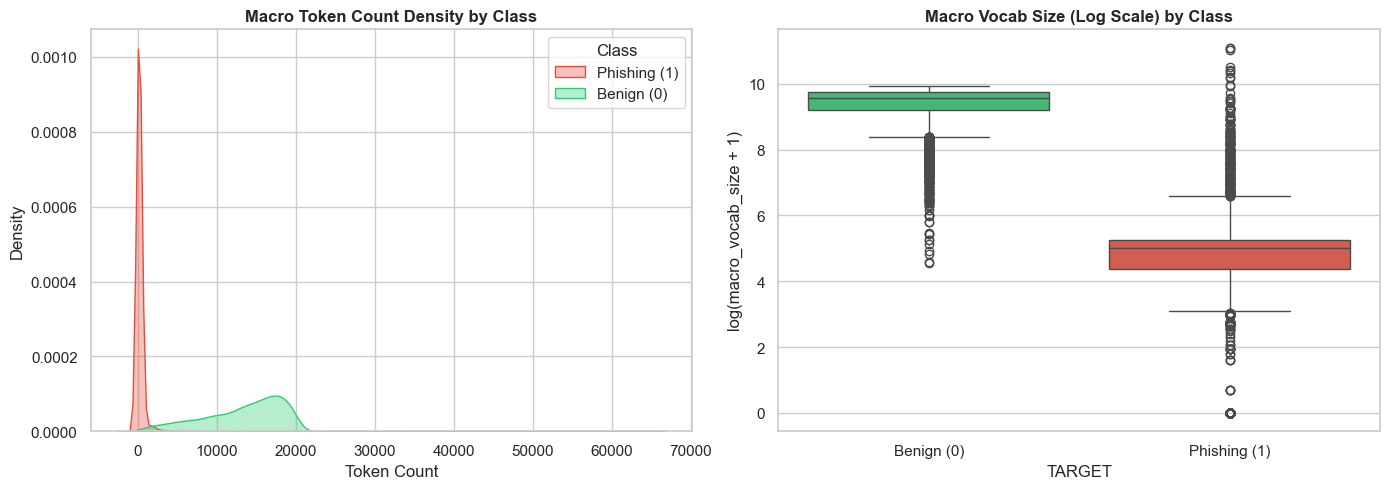

In [13]:
# Detailed inspection of macro token count and vocabulary size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=train, x="macro_token_count", hue="TARGET", common_norm=False,
            palette=["#2ecc71", "#e74c3c"], fill=True, ax=axes[0], alpha=0.35)
axes[0].set_title("Macro Token Count Density by Class", fontweight="bold")
axes[0].set_xlabel("Token Count")
axes[0].legend(["Phishing (1)", "Benign (0)"], title="Class")

sns.boxplot(data=train, x="TARGET", y=np.log1p(train["macro_vocab_size"]),
            hue="TARGET", palette=["#2ecc71", "#e74c3c"], legend=False, ax=axes[1])
axes[1].set_title("Macro Vocab Size (Log Scale) by Class", fontweight="bold")
axes[1].set_xticks([0, 1], labels=["Benign (0)", "Phishing (1)"])
axes[1].set_ylabel("log(macro_vocab_size + 1)")

plt.tight_layout()
plt.show()


<a name="sec3_2_5"></a>
#### 3.2.5 Heavy-Tailed Attributes: Raw vs. Logarithmic Transformation
Compare raw vs log-transformed distributions for skewed attributes.


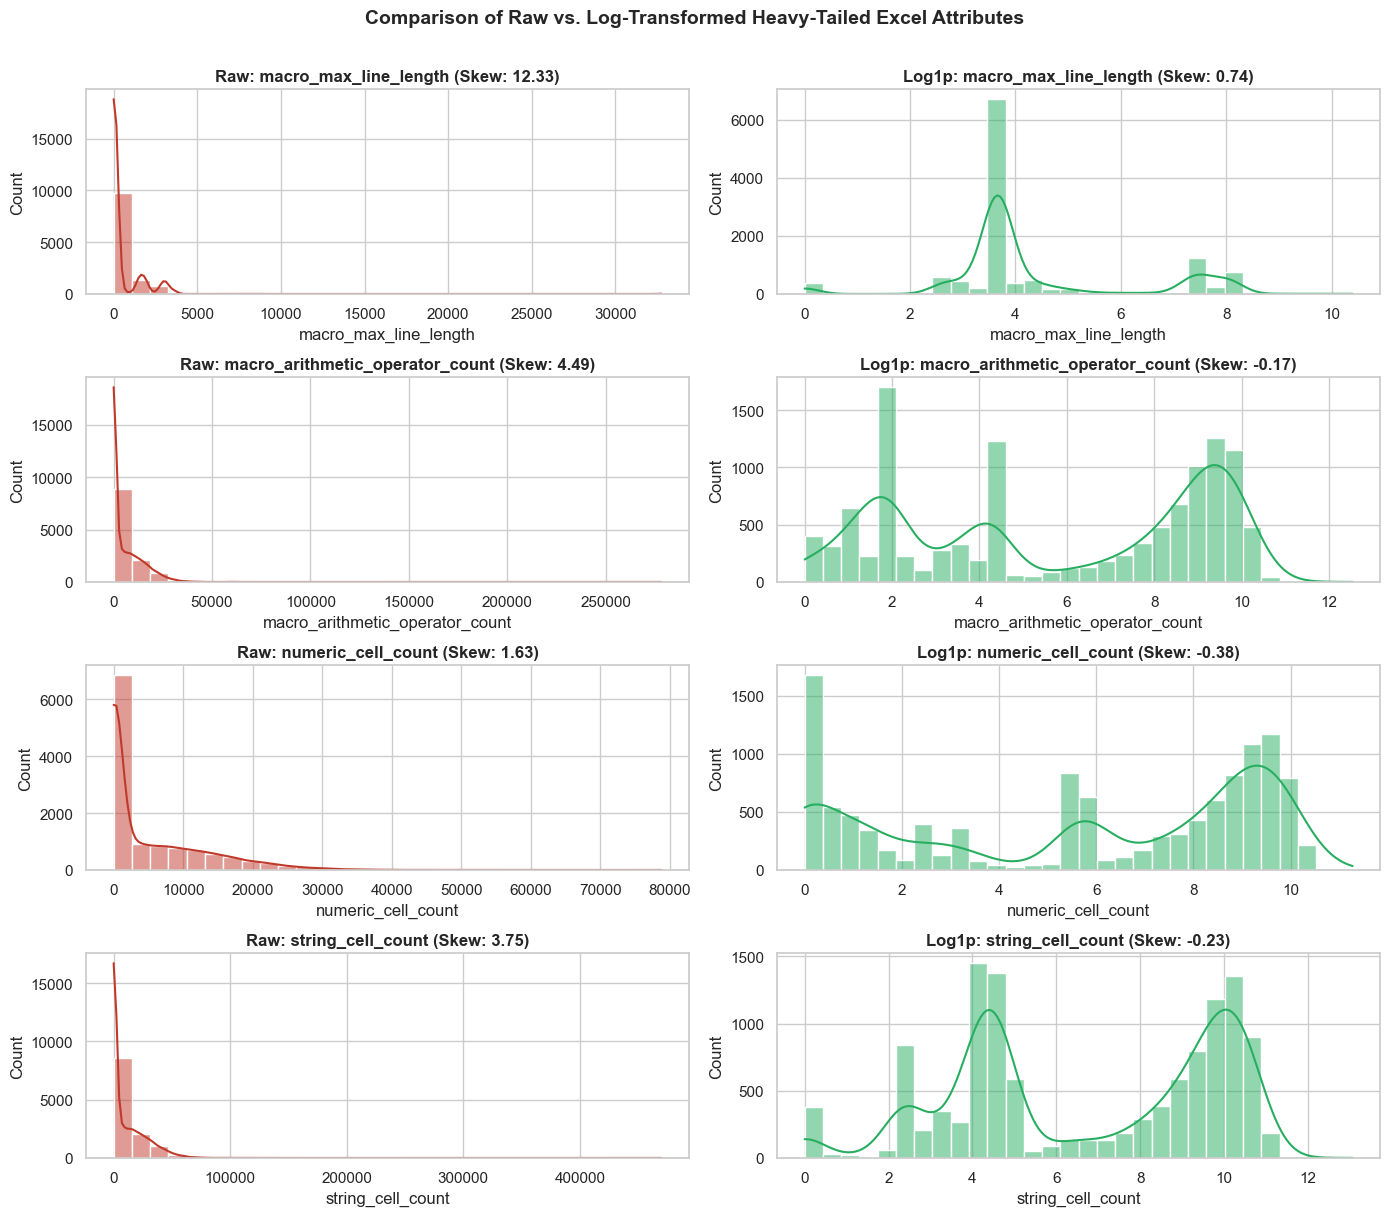

In [14]:
# Raw vs Log-Transformed comparison for heavy-tailed structural attributes
heavy_cols = ["macro_max_line_length", "macro_arithmetic_operator_count", "numeric_cell_count", "string_cell_count"]

fig, axes = plt.subplots(len(heavy_cols), 2, figsize=(14, 12))

for i, col in enumerate(heavy_cols):
    sns.histplot(train[col], kde=True, ax=axes[i, 0], color="#c0392b", bins=30)
    axes[i, 0].set_title(f"Raw: {col} (Skew: {train[col].skew():.2f})", fontweight="bold")
    
    log_vals = np.log1p(train[col])
    sns.histplot(log_vals, kde=True, ax=axes[i, 1], color="#27ae60", bins=30)
    axes[i, 1].set_title(f"Log1p: {col} (Skew: {log_vals.skew():.2f})", fontweight="bold")

plt.suptitle("Comparison of Raw vs. Log-Transformed Heavy-Tailed Excel Attributes", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


<a name="sec3_2_6"></a>
#### 3.2.6 Cell Structure & Remote Template Infiltration
Examine text entropy and remote template presence by class.


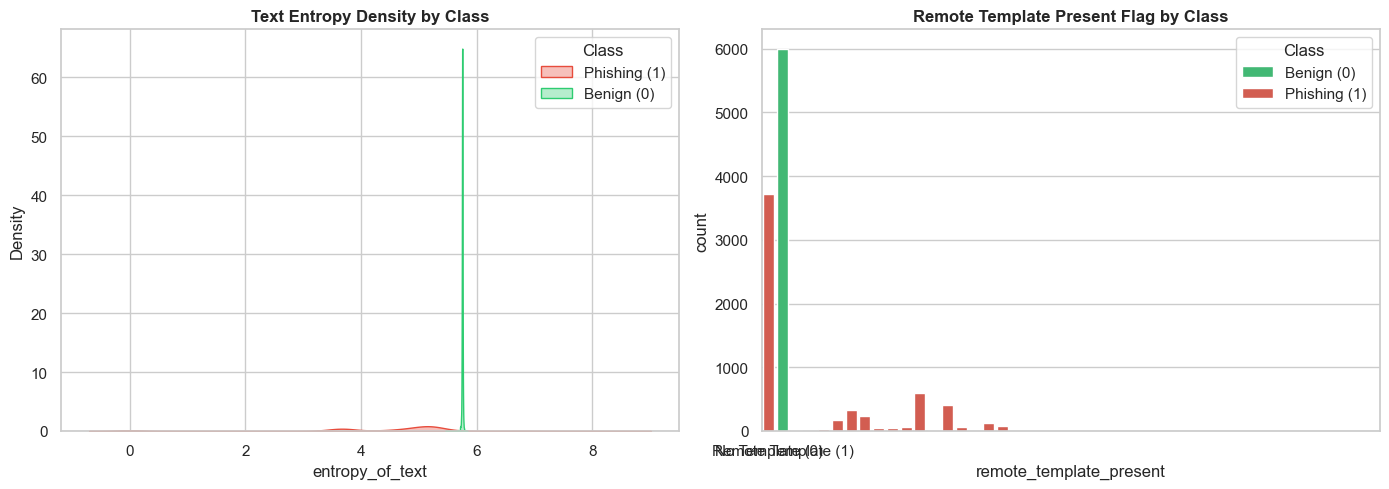

In [15]:
# Cell structure & remote template presence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=train, x="entropy_of_text", hue="TARGET", common_norm=False,
            palette=["#2ecc71", "#e74c3c"], fill=True, ax=axes[0], alpha=0.35)
axes[0].set_title("Text Entropy Density by Class", fontweight="bold")
axes[0].legend(["Phishing (1)", "Benign (0)"], title="Class")

sns.countplot(data=train, x="remote_template_present", hue="TARGET",
              palette=["#2ecc71", "#e74c3c"], ax=axes[1])
axes[1].set_title("Remote Template Present Flag by Class", fontweight="bold")
axes[1].set_xticks([0, 1], labels=["No Template (0)", "Remote Template (1)"])
axes[1].legend(["Benign (0)", "Phishing (1)"], title="Class")

plt.tight_layout()
plt.show()


<a name="sec3_2_7"></a>
#### 3.2.7 Comprehensive Evenness Summary Table & Correlation Heatmap
Compute feature correlations with `TARGET`.


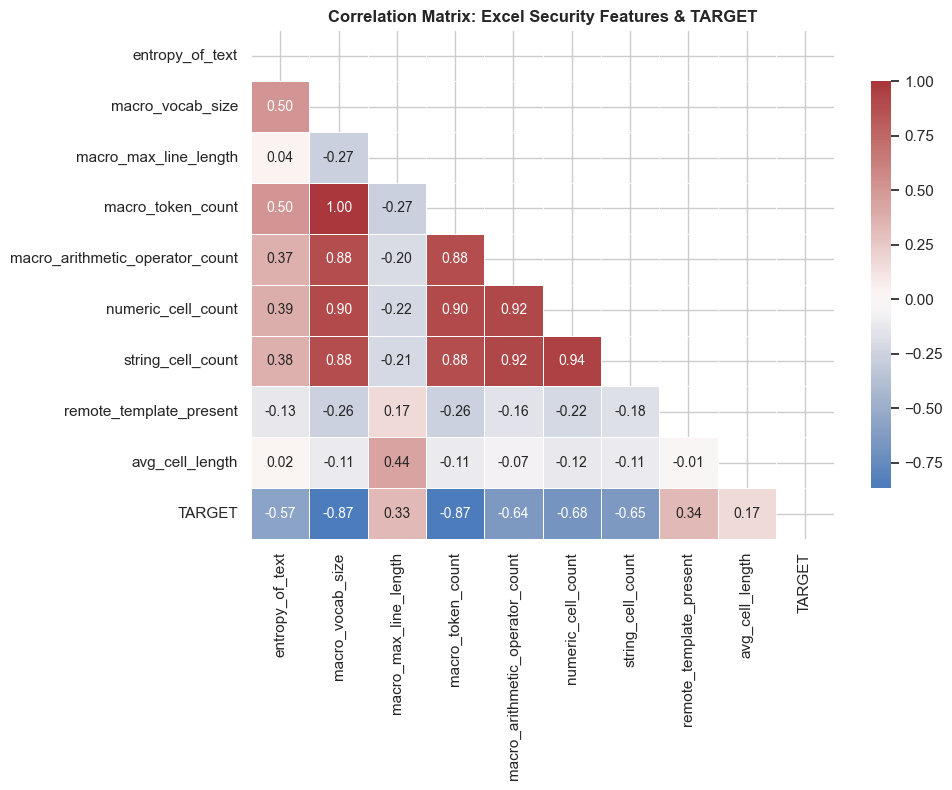

,Pearson Correlation (r)
remote_template_present,0.3353
macro_max_line_length,0.3346
avg_cell_length,0.1658
entropy_of_text,-0.5734
macro_arithmetic_operator_count,-0.6400
string_cell_count,-0.6457
numeric_cell_count,-0.6798
macro_token_count,-0.8660
macro_vocab_size,-0.8660


In [16]:
# Correlation heatmap and summary table
corr_matrix = train[core_features + ["TARGET"]].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", center=0,
            mask=mask, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix: Excel Security Features & TARGET", fontweight="bold")
plt.tight_layout()
plt.show()

top_corr = corr_matrix["TARGET"].drop("TARGET").sort_values(ascending=False)
display(pd.DataFrame({"Pearson Correlation (r)": top_corr}))


<a name="sec3_3"></a>
### 3.3 Summary Findings & Next Steps
- Macro features (`macro_vocab_size`, `macro_token_count`, `macro_arithmetic_operator_count`) are primary discriminators.
- Text entropy and remote template presence provide strong non-linear signals.
- Models will be trained with `StandardScaler` to ensure numerical stability.


<a name="sec4"></a>
## 4. Preprocessing and Feature Creation
Construct log-transformed representations and standardize features.


In [17]:
# Preprocessing: engineer log-transformed attributes
train_proc = train.copy()
test_proc = test.copy()

for col in ["macro_max_line_length", "macro_arithmetic_operator_count", "numeric_cell_count", "string_cell_count"]:
    train_proc[f"{col}_log"] = np.log1p(train_proc[col])
    test_proc[f"{col}_log"] = np.log1p(test_proc[col])

print(f"Engineered log features added. Feature count: {train_proc.shape[1] - 2} attributes.")


Engineered log features added. Feature count: 15 attributes.


<a name="sec5"></a>
## 5. Building the Machine Learning Model
We build and validate Logistic Regression, Decision Tree, Random Forest, and a Voting Ensemble.


<a name="sec5_1"></a>
### 5.1 Import Additional Libraries
Import scikit-learn models and metrics.


In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve
)
import joblib

print("Machine learning libraries imported successfully!")


Machine learning libraries imported successfully!


<a name="sec5_2"></a>
### 5.2 Preparing the Data & Standardization
Extract features, standardize with `StandardScaler`, and save CSV datasets to `output/excel output/`.


In [19]:
# Extract feature arrays
X = train[core_features].values
y = train["TARGET"].values
X_test = test[core_features].values

# Standardization
sc = StandardScaler()
sc.fit(X)
X_std = sc.transform(X)
X_test_std = sc.transform(X_test)

print(f"Standardized features successfully (mean ≈ 0, std ≈ 1).\n")

X_std_df = pd.DataFrame(X_std, columns=core_features)
X_test_std_df = pd.DataFrame(X_test_std, columns=core_features)

print("--- Standardized Train Data (X_std - 5 samples) ---")
display(X_std_df.head())

print("\n--- Standardized Test Data (X_test_std - 5 samples) ---")
display(X_test_std_df.head())

# Assemble full DataFrames with identifiers and target
train_std_df = train[["file_name"]].copy()
train_std_df[core_features] = X_std_df
train_std_df["TARGET"] = train["TARGET"].values

test_std_df = test[["file_name"]].copy()
test_std_df[core_features] = X_test_std_df
if "TARGET" in test.columns:
    test_std_df["TARGET"] = test["TARGET"].values

# Output directories
current_dir = Path(os.getcwd())
excel_output_dir = current_dir / "output" / "excel output"
excel_output_dir.mkdir(parents=True, exist_ok=True)
excel_output_dir_alt = current_dir / "output" / "Excel output"
excel_output_dir_alt.mkdir(parents=True, exist_ok=True)

# Save standardized and raw split CSV files
train_std_path = excel_output_dir / "train_standardized.csv"
test_std_path = excel_output_dir / "test_standardized.csv"
train_raw_path = excel_output_dir / "train.csv"
test_raw_path = excel_output_dir / "test.csv"

train_std_df.to_csv(train_std_path, index=False)
test_std_df.to_csv(test_std_path, index=False)
train.to_csv(train_raw_path, index=False)
test.to_csv(test_raw_path, index=False)

train_std_df.to_csv(excel_output_dir_alt / "train_standardized.csv", index=False)
test_std_df.to_csv(excel_output_dir_alt / "test_standardized.csv", index=False)
train.to_csv(excel_output_dir_alt / "train.csv", index=False)
test.to_csv(excel_output_dir_alt / "test.csv", index=False)

print(f"\nSuccessfully saved datasets to 'excel output' folder:")
print(f" - Standardized Train : {train_std_path} (shape: {train_std_df.shape})")
print(f" - Standardized Test  : {test_std_path} (shape: {test_std_df.shape})")
print(f" - Raw Train Split    : {train_raw_path} (shape: {train.shape})")
print(f" - Raw Test Split     : {test_raw_path} (shape: {test.shape})")


Standardized features successfully (mean ≈ 0, std ≈ 1).

--- Standardized Train Data (X_std - 5 samples) ---


,entropy_of_text,macro_vocab_size,macro_max_line_length,macro_token_count,macro_arithmetic_operator_count,numeric_cell_count,string_cell_count,remote_template_present,avg_cell_length
0,0.5690,0.5737,-0.3356,0.5737,0.0118,-0.0000,-0.0016,-0.3353,-0.1662
1,0.1537,-0.8958,1.5886,-0.8958,-0.6699,-0.7134,-0.6791,-0.4932,0.9303
2,0.5775,1.4133,-0.3342,1.4133,1.2582,1.3217,1.2747,-0.3353,-0.1657
3,0.5804,1.3253,-0.3342,1.3253,1.0151,1.0902,1.0563,-0.3353,-0.1657
4,0.5823,0.8843,-0.3356,0.8843,0.3047,0.3272,0.3189,-0.3353,-0.1658



--- Standardized Test Data (X_test_std - 5 samples) ---


,entropy_of_text,macro_vocab_size,macro_max_line_length,macro_token_count,macro_arithmetic_operator_count,numeric_cell_count,string_cell_count,remote_template_present,avg_cell_length
0,0.5624,1.2650,-0.3349,1.2650,0.9490,0.9942,0.9259,-0.3353,-0.1660
1,0.5757,-0.1104,-0.3391,-0.1104,-0.4324,-0.4638,-0.4343,-0.3353,-0.1657
2,0.5717,0.2685,-0.3342,0.2685,-0.2461,-0.2423,-0.2431,-0.3353,-0.1662
3,0.0587,-0.8964,2.1966,-0.8964,-0.6699,-0.7134,-0.6793,-0.4932,1.6111
4,0.5751,1.3839,-0.3335,1.3839,1.2178,1.2742,1.2210,-0.3353,-0.1657



Successfully saved datasets to 'excel output' folder:
 - Standardized Train : D:\codingProject\ExplainPhish\output\excel output\train_standardized.csv (shape: (12000, 11))
 - Standardized Test  : D:\codingProject\ExplainPhish\output\excel output\test_standardized.csv (shape: (8000, 11))
 - Raw Train Split    : D:\codingProject\ExplainPhish\output\excel output\train.csv (shape: (12000, 13))
 - Raw Test Split     : D:\codingProject\ExplainPhish\output\excel output\test.csv (shape: (8000, 13))


<a name="sec5_3"></a>
### 5.3 Training the Model
Perform a 70/30 stratified holdout split on training data and train the three models.


In [20]:
# Split the standardized training data into 70% train and 30% validation
X_train, X_valid, y_train, y_valid = train_test_split(
    X_std, y, test_size=0.3, stratify=y, random_state=0
)

print(f"Train size: {X_train.shape[0]:,} samples | Validation size: {X_valid.shape[0]:,} samples")


Train size: 8,400 samples | Validation size: 3,600 samples


In [21]:
# Model 1: Logistic Regression
lr = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=0)
lr.fit(X_train, y_train)

lr_val_auc = roc_auc_score(y_valid, lr.predict_proba(X_valid)[:, 1])
lr_val_acc = accuracy_score(y_valid, lr.predict(X_valid))
print(f"Logistic Regression Validation ROC-AUC: {lr_val_auc:.4f} | Accuracy: {lr_val_acc:.4f}")


Logistic Regression Validation ROC-AUC: 0.9984 | Accuracy: 0.9967


In [22]:
# Model 2: Decision Tree
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, class_weight="balanced", random_state=0)
dt.fit(X_train, y_train)

dt_val_auc = roc_auc_score(y_valid, dt.predict_proba(X_valid)[:, 1])
dt_val_acc = accuracy_score(y_valid, dt.predict(X_valid))
print(f"Decision Tree Validation ROC-AUC: {dt_val_auc:.4f} | Accuracy: {dt_val_acc:.4f}")


Decision Tree Validation ROC-AUC: 0.9994 | Accuracy: 0.9992


In [23]:
# Model 3: Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=16, class_weight="balanced", random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)

rf_val_auc = roc_auc_score(y_valid, rf.predict_proba(X_valid)[:, 1])
rf_val_acc = accuracy_score(y_valid, rf.predict(X_valid))
print(f"Random Forest Validation ROC-AUC: {rf_val_auc:.4f} | Accuracy: {rf_val_acc:.4f}")


Random Forest Validation ROC-AUC: 1.0000 | Accuracy: 0.9994


<a name="sec5_4"></a>
### 5.4 Visualizations for Random Forest, Decision Tree & Logistic Regression
Comprehensive diagnostic visualizations for all models.


<a name="sec5_4_1"></a>
#### 5.4.1 Logistic Regression Visualizations
Feature coefficients and sigmoid probability separation curve.


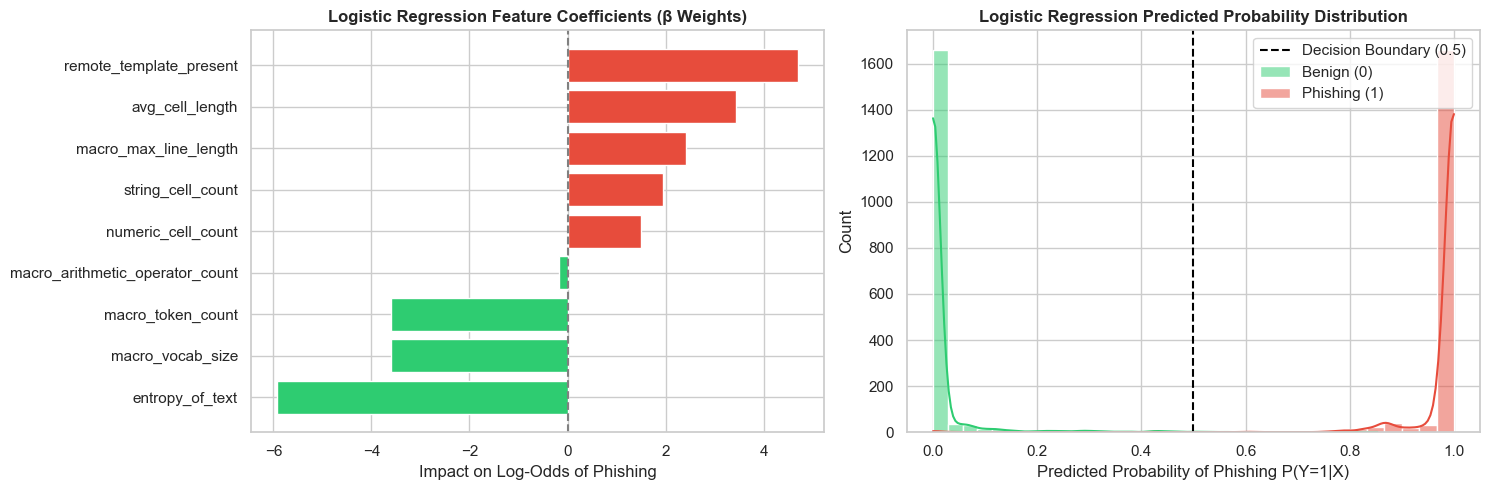

In [24]:
# Logistic Regression Feature Coefficients and Probability Separation
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

coef_series = pd.Series(lr.coef_[0], index=core_features).sort_values()
colors = ["#2ecc71" if c < 0 else "#e74c3c" for c in coef_series.values]
axes[0].barh(coef_series.index, coef_series.values, color=colors)
axes[0].set_title("Logistic Regression Feature Coefficients (β Weights)", fontweight="bold")
axes[0].set_xlabel("Impact on Log-Odds of Phishing")
axes[0].axvline(0, color="gray", linestyle="--")

lr_probs = lr.predict_proba(X_valid)[:, 1]
sns.histplot(lr_probs[y_valid == 0], color="#2ecc71", label="Benign (0)", kde=True, ax=axes[1], bins=30, alpha=0.5)
sns.histplot(lr_probs[y_valid == 1], color="#e74c3c", label="Phishing (1)", kde=True, ax=axes[1], bins=30, alpha=0.5)
axes[1].axvline(0.5, color="black", linestyle="--", label="Decision Boundary (0.5)")
axes[1].set_title("Logistic Regression Predicted Probability Distribution", fontweight="bold")
axes[1].set_xlabel("Predicted Probability of Phishing P(Y=1|X)")
axes[1].legend()

plt.tight_layout()
plt.show()


<a name="sec5_4_2"></a>
#### 5.4.2 Decision Tree Visualizations
Decision tree graph structure and Gini feature importances.


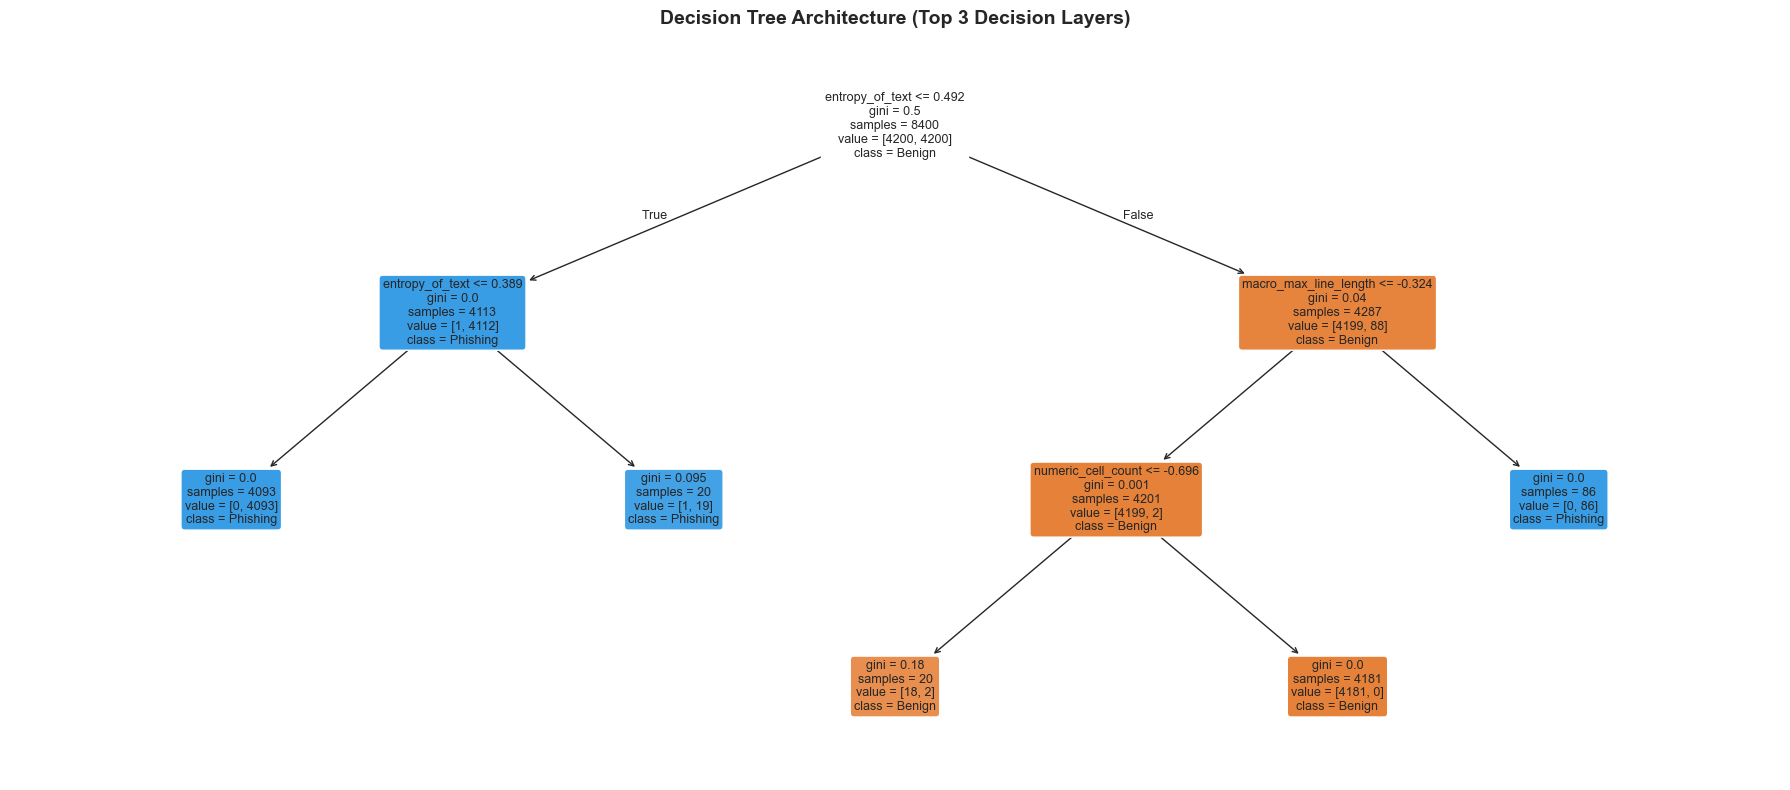

In [25]:
# Decision Tree Structure Graph
plt.figure(figsize=(18, 8))
plot_tree(
    dt,
    feature_names=core_features,
    class_names=["Benign", "Phishing"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)
plt.title("Decision Tree Architecture (Top 3 Decision Layers)", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()


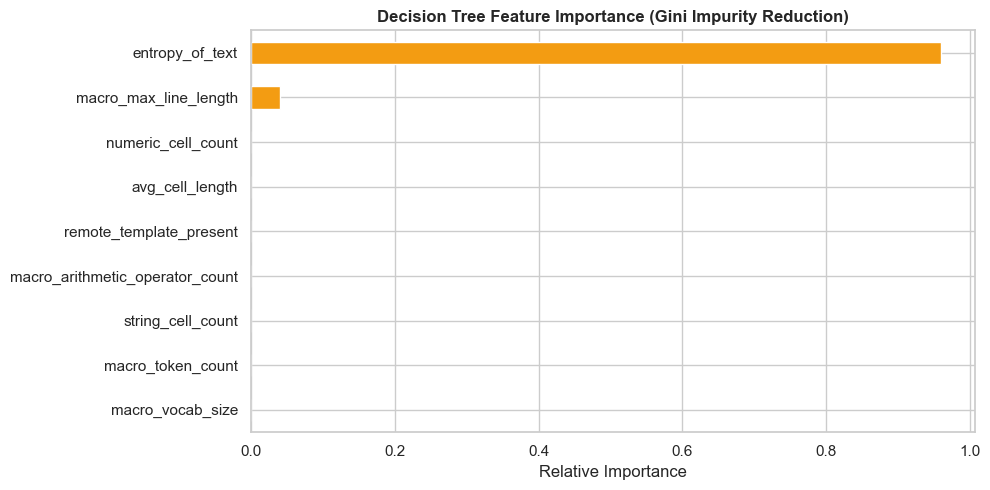

In [26]:
# Decision Tree Feature Importance Plot
dt_importances = pd.Series(dt.feature_importances_, index=core_features).sort_values(ascending=True)

plt.figure(figsize=(10, 5))
dt_importances.plot(kind="barh", color="#f39c12")
plt.title("Decision Tree Feature Importance (Gini Impurity Reduction)", fontweight="bold")
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()


<a name="sec5_4_3"></a>
#### 5.4.3 Random Forest Visualizations
MDI importance with inter-tree standard deviation and tree depth distribution.


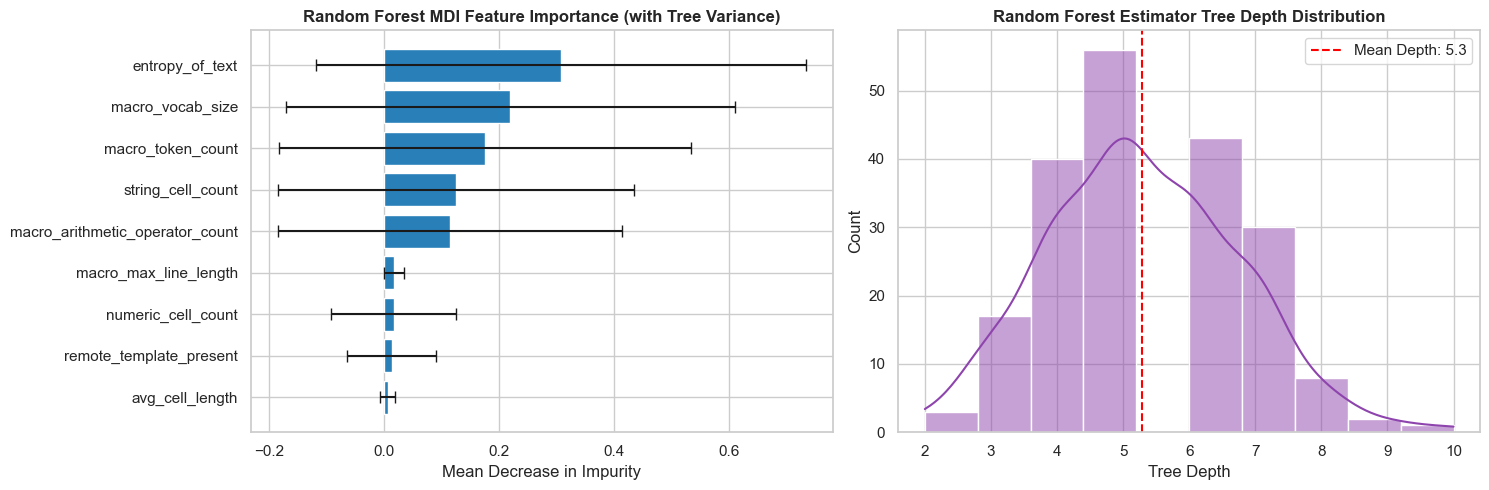

In [27]:
# Random Forest Feature Importance with Inter-Tree Standard Deviation
importances = rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)
indices = np.argsort(importances)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(range(len(indices)), importances[indices], xerr=std[indices], color="#2980b9", capsize=4, align="center")
axes[0].set_yticks(range(len(indices)))
axes[0].set_yticklabels([core_features[i] for i in indices])
axes[0].set_title("Random Forest MDI Feature Importance (with Tree Variance)", fontweight="bold")
axes[0].set_xlabel("Mean Decrease in Impurity")

tree_depths = [tree.tree_.max_depth for tree in rf.estimators_]
sns.histplot(tree_depths, bins=10, kde=True, ax=axes[1], color="#8e44ad")
axes[1].axvline(np.mean(tree_depths), color="red", linestyle="--", label=f"Mean Depth: {np.mean(tree_depths):.1f}")
axes[1].set_title("Random Forest Estimator Tree Depth Distribution", fontweight="bold")
axes[1].set_xlabel("Tree Depth")
axes[1].legend()

plt.tight_layout()
plt.show()


<a name="sec5_4_4"></a>
#### 5.4.4 Multi-Model Comparison (ROC Curves, Confusion Matrices, & Metrics)
Side-by-side benchmark of all algorithms.


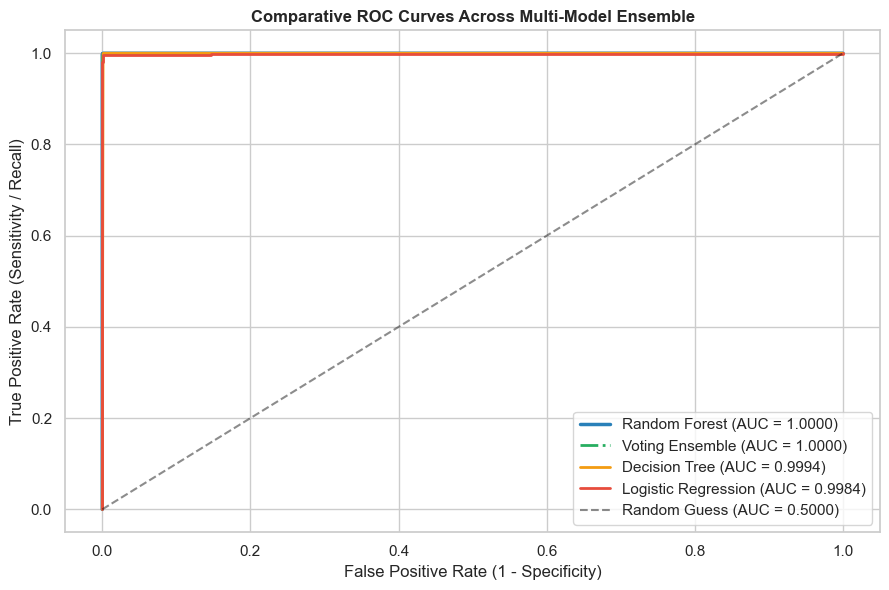

In [28]:
# Generate Predictions & ROC Curves for all 3 models and Voting Ensemble
p_lr = lr.predict_proba(X_valid)[:, 1]
p_dt = dt.predict_proba(X_valid)[:, 1]
p_rf = rf.predict_proba(X_valid)[:, 1]
p_vote = (p_lr + p_dt + p_rf) / 3

fpr_lr, tpr_lr, _ = roc_curve(y_valid, p_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_valid, p_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_valid, p_rf)
fpr_vote, tpr_vote, _ = roc_curve(y_valid, p_vote)

plt.figure(figsize=(9, 6))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {rf_val_auc:.4f})", color="#2980b9", lw=2.5)
plt.plot(fpr_vote, tpr_vote, label=f"Voting Ensemble (AUC = {roc_auc_score(y_valid, p_vote):.4f})", color="#27ae60", lw=2, linestyle="-.")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {dt_val_auc:.4f})", color="#f39c12", lw=2)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {lr_val_auc:.4f})", color="#e74c3c", lw=2)
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random Guess (AUC = 0.5000)")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity / Recall)")
plt.title("Comparative ROC Curves Across Multi-Model Ensemble", fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


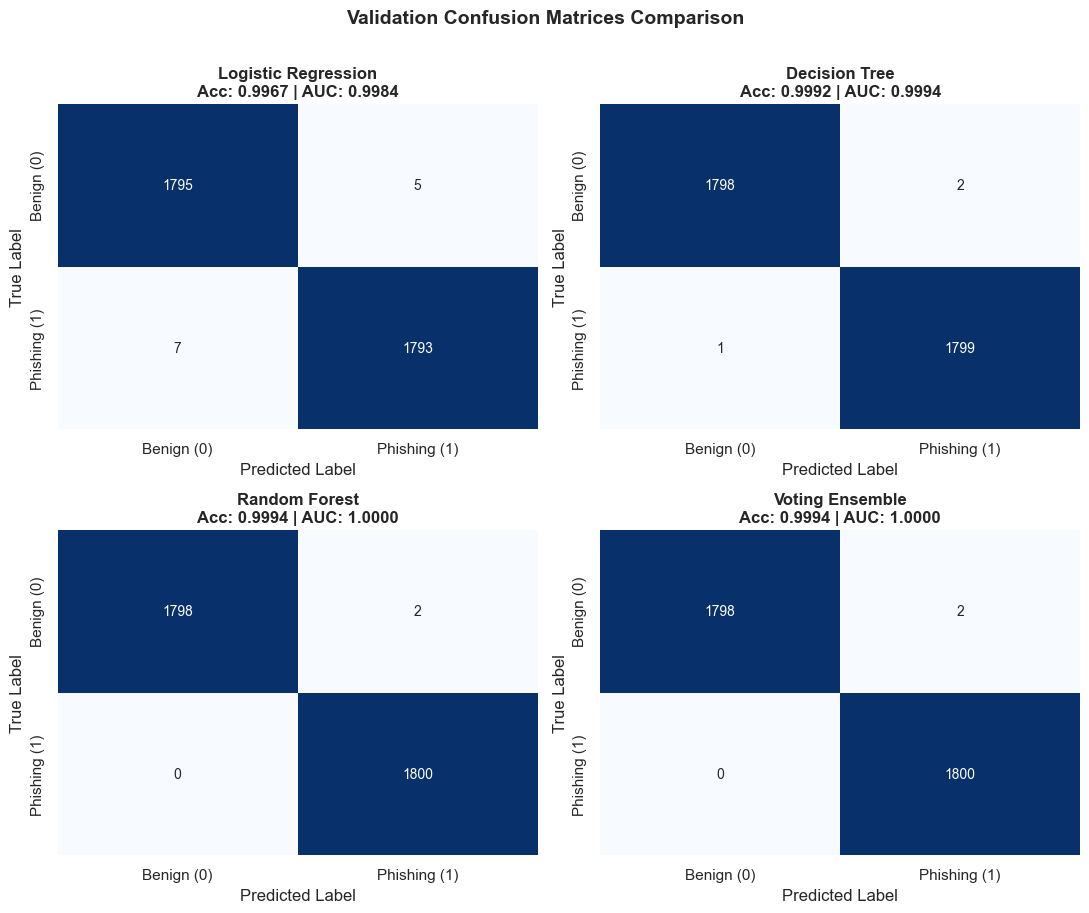

In [29]:
# Side-by-side Confusion Matrices (2x2 Grid)
models_dict = {
    "Logistic Regression": (lr.predict(X_valid), lr_val_auc),
    "Decision Tree": (dt.predict(X_valid), dt_val_auc),
    "Random Forest": (rf.predict(X_valid), rf_val_auc),
    "Voting Ensemble": ((p_vote >= 0.5).astype(int), roc_auc_score(y_valid, p_vote))
}

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for idx, (m_name, (preds, auc_sc)) in enumerate(models_dict.items()):
    ax = axes[idx]
    cm = confusion_matrix(y_valid, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["Benign (0)", "Phishing (1)"],
                yticklabels=["Benign (0)", "Phishing (1)"])
    acc = accuracy_score(y_valid, preds)
    ax.set_title(f"{m_name}\nAcc: {acc:.4f} | AUC: {auc_sc:.4f}", fontweight="bold")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.suptitle("Validation Confusion Matrices Comparison", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.9967,0.9972,0.9961,0.9967,0.9984
Decision Tree,0.9992,0.9989,0.9994,0.9992,0.9994
Random Forest,0.9994,0.9989,1.0000,0.9994,1.0000
Voting Ensemble,0.9994,0.9989,1.0000,0.9994,1.0000


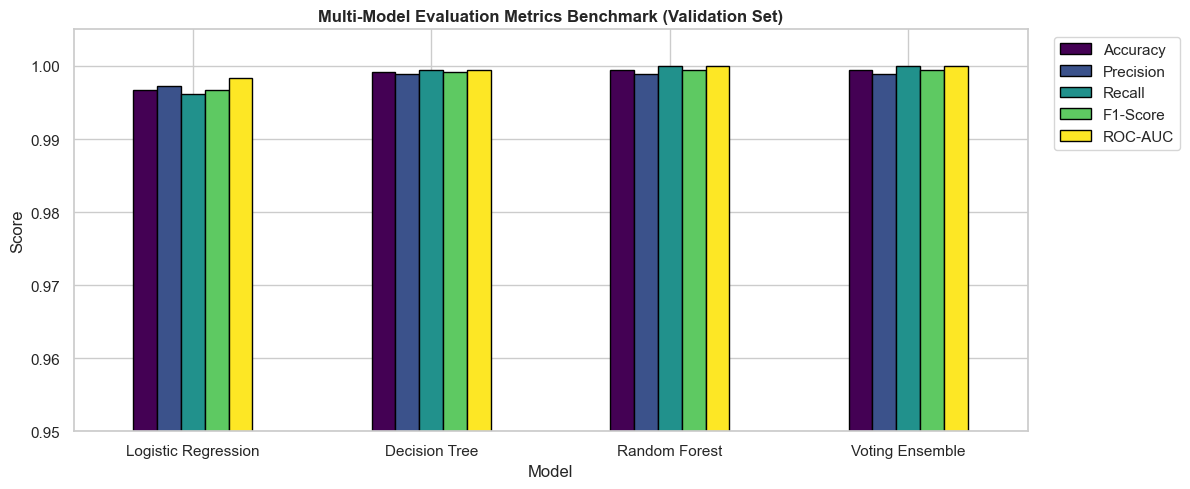

In [30]:
# Overall Performance Metrics Comparison Table & Bar Chart
metrics_list = []
for m_name, (preds, auc_sc) in models_dict.items():
    metrics_list.append({
        "Model": m_name,
        "Accuracy": accuracy_score(y_valid, preds),
        "Precision": precision_score(y_valid, preds),
        "Recall": recall_score(y_valid, preds),
        "F1-Score": f1_score(y_valid, preds),
        "ROC-AUC": auc_sc
    })

metrics_df = pd.DataFrame(metrics_list).set_index("Model")
display(metrics_df.round(4))

ax = metrics_df.plot(kind="bar", figsize=(12, 5), colormap="viridis", edgecolor="black")
plt.title("Multi-Model Evaluation Metrics Benchmark (Validation Set)", fontweight="bold")
plt.ylabel("Score")
plt.ylim(0.95, 1.005)
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


<a name="sec5_5"></a>
### 5.5 (Optional) Use Voting Learning of 3 Different Models
Evaluate majority voting and soft ensemble probabilities.


In [31]:
# Voting learning of 3 different models (soft voting consensus)
p_vote_valid = (
    rf.predict_proba(X_valid)[:, 1] +
    dt.predict_proba(X_valid)[:, 1] +
    lr.predict_proba(X_valid)[:, 1]
) / 3

vote_auc = roc_auc_score(y_valid, p_vote_valid)
vote_acc = accuracy_score(y_valid, (p_vote_valid >= 0.5).astype(int))

print(f"=== 3-Model Voting Ensemble Validation Performance ===")
print(f"Voting Validation ROC-AUC : {vote_auc:.4f}")
print(f"Voting Validation Accuracy: {vote_acc:.4f}")


=== 3-Model Voting Ensemble Validation Performance ===
Voting Validation ROC-AUC : 1.0000
Voting Validation Accuracy: 0.9994


<a name="sec5_6"></a>
### 5.6 Saving Models into One Folder for Multimodal Voting (InterfaceExplainPhish)
Bundle all three models, the preprocessor, feature schema, and metadata into unified directories:
- `rf_model.joblib`: Random Forest Classifier
- `dt_model.joblib`: Decision Tree Classifier
- `lr_model.joblib`: Logistic Regression Classifier
- `scaler.joblib`: StandardScaler fitted on 9 Excel features
- `selected_features.json`: Exact list of required feature names
- `metadata.json`: Architectural details and validation benchmark scores


In [32]:
import json
import joblib

export_dirs = [
    current_dir / "models" / "excel",
    current_dir / "InterfaceExplainPhish" / "models" / "excel",
    current_dir / "googleCollab" / "models" / "excel",
]

for d in export_dirs:
    d.mkdir(parents=True, exist_ok=True)
    
    joblib.dump(rf, d / "rf_model.joblib")
    joblib.dump(dt, d / "dt_model.joblib")
    joblib.dump(lr, d / "lr_model.joblib")
    joblib.dump(sc, d / "scaler.joblib")
    
    with open(d / "selected_features.json", "w") as f:
        json.dump(core_features, f, indent=2)
        
    meta = {
        "format": "excel",
        "models": ["random_forest", "decision_tree", "logistic_regression"],
        "n_features": len(core_features),
        "features": core_features,
        "validation_metrics": {
            "logistic_regression": {"roc_auc": round(lr_val_auc, 4)},
            "decision_tree": {"roc_auc": round(dt_val_auc, 4)},
            "random_forest": {"roc_auc": round(rf_val_auc, 4)},
            "voting_ensemble": {"roc_auc": round(vote_auc, 4)}
        }
    }
    with open(d / "metadata.json", "w") as f:
        json.dump(meta, f, indent=2)

print(f"Successfully saved all 3 models, scaler, and metadata into unified Excel model folders:")
for d in export_dirs:
    print(f" -> {d.resolve()}")


Successfully saved all 3 models, scaler, and metadata into unified Excel model folders:
 -> D:\codingProject\ExplainPhish\models\excel
 -> D:\codingProject\ExplainPhish\InterfaceExplainPhish\models\excel
 -> D:\codingProject\ExplainPhish\googleCollab\models\excel


#### Demonstrating Multimodal Voting on an Extracted Excel Sample
Test voting consensus on an extracted Excel feature vector.


In [33]:
# Multimodal consensus voting function using the saved model artifacts
def predict_excel_multimodal_voting(feature_dict, models_directory):
    p = Path(models_directory)
    m_rf = joblib.load(p / "rf_model.joblib")
    m_dt = joblib.load(p / "dt_model.joblib")
    m_lr = joblib.load(p / "lr_model.joblib")
    m_sc = joblib.load(p / "scaler.joblib")
    with open(p / "selected_features.json", "r") as f:
        req_features = json.load(f)
        
    df_sample = pd.DataFrame([feature_dict])[req_features]
    sample_std = m_sc.transform(df_sample.values)
    
    prob_rf = float(m_rf.predict_proba(sample_std)[0, 1])
    prob_dt = float(m_dt.predict_proba(sample_std)[0, 1])
    prob_lr = float(m_lr.predict_proba(sample_std)[0, 1])
    
    mean_prob = (prob_rf + prob_dt + prob_lr) / 3
    malicious_votes = sum([prob_rf >= 0.5, prob_dt >= 0.5, prob_lr >= 0.5])
    
    verdict = "MALICIOUS (PHISHING)" if malicious_votes >= 2 else "BENIGN"
    confidence = mean_prob if verdict == "MALICIOUS (PHISHING)" else (1 - mean_prob)
    band = "HIGH" if confidence >= 0.85 else ("MEDIUM" if confidence >= 0.65 else "LOW")
    
    return {
        "verdict": verdict,
        "confidence_score": f"{confidence * 100:.1f}% ({band})",
        "consensus_agreement": f"{malicious_votes}/3 models voted Malicious",
        "mean_phishing_probability": round(mean_prob, 4),
        "model_predictions": [
            {"model": "Random Forest", "prediction": "MALICIOUS" if prob_rf >= 0.5 else "BENIGN", "probability": f"{prob_rf*100:.1f}%"},
            {"model": "Decision Tree", "prediction": "MALICIOUS" if prob_dt >= 0.5 else "BENIGN", "probability": f"{prob_dt*100:.1f}%"},
            {"model": "Logistic Regression", "prediction": "MALICIOUS" if prob_lr >= 0.5 else "BENIGN", "probability": f"{prob_lr*100:.1f}%"}
        ]
    }

# Example test: simulate an extracted Excel sample
sample_test_features = {
    "entropy_of_text": 4.85,
    "macro_vocab_size": 42,
    "macro_max_line_length": 180,
    "macro_token_count": 210,
    "macro_arithmetic_operator_count": 15,
    "numeric_cell_count": 12,
    "string_cell_count": 45,
    "remote_template_present": 1,
    "avg_cell_length": 8.4
}

demo_result = predict_excel_multimodal_voting(sample_test_features, current_dir / "models" / "excel")
print(json.dumps(demo_result, indent=2))


{
  "verdict": "MALICIOUS (PHISHING)",
  "confidence_score": "99.3% (HIGH)",
  "consensus_agreement": "3/3 models voted Malicious",
  "mean_phishing_probability": 0.9931,
  "model_predictions": [
    {
      "model": "Random Forest",
      "prediction": "MALICIOUS",
      "probability": "98.5%"
    },
    {
      "model": "Decision Tree",
      "prediction": "MALICIOUS",
      "probability": "100.0%"
    },
    {
      "model": "Logistic Regression",
      "prediction": "MALICIOUS",
      "probability": "99.4%"
    }
  ]
}


<a name="sec6"></a>
## 6. Creating Prediction Results
Generate predictions on test data and export `submission.csv` to `output/excel output/`.


<a name="sec6_1"></a>
### 6.1 Predicting on the test data
Predict probabilities for the test partition using the top-performing ensemble.


In [34]:
# Make predictions for the test data using the voting ensemble
pred = (
    rf.predict_proba(X_test_std)[:, 1] +
    dt.predict_proba(X_test_std)[:, 1] +
    lr.predict_proba(X_test_std)[:, 1]
) / 3

print(f"Generated {len(pred):,} test predictions.")


Generated 8,000 test predictions.

<a name="sec6_2"></a>
### 6.2 Saving the Prediction as CSV File in 'excel output' Folder
Format predictions into `submission.csv`.


In [35]:
# Put the prediction into the format of submission
sample_sub = pd.DataFrame({
    "file_name": test["file_name"].values,
    "TARGET": pred
})
sample_sub.head(10)


,file_name,TARGET
0,benign_sample_6706.xlsx,0.0000
1,benign_sample_644.xlsx,0.0035
2,benign_sample_5737.xlsx,0.0005
3,70e68c39f568687889a7d8accbf9d56d22510f3c1f8288...,1.0000
4,benign_sample_5622.xlsx,0.0000
5,ae07b159e7a3695ed1b6936f7378760800fd15d75fa25e...,1.0000
6,813d664306901ebef7ff32363699a13fe6775bcb5f5ecd...,1.0000
7,benign_sample_626.xlsx,0.0010
8,benign_sample_3146.xlsx,0.0000
9,benign_sample_8737.xlsx,0.0001


In [36]:
# Save submission to 'excel output' directory
excel_output_dir = current_dir / "output" / "excel output"
excel_output_dir.mkdir(parents=True, exist_ok=True)
excel_output_dir_alt = current_dir / "output" / "Excel output"
excel_output_dir_alt.mkdir(parents=True, exist_ok=True)

output_file = excel_output_dir / "submission.csv"
output_file_alt = excel_output_dir_alt / "submission.csv"

sample_sub.to_csv(output_file, index=False)
sample_sub.to_csv(output_file_alt, index=False)

print(f"Successfully saved prediction results to:\n - {output_file.resolve()}\n - {output_file_alt.resolve()}")


Successfully saved prediction results to:
 - D:\codingProject\ExplainPhish\output\excel output\submission.csv
 - D:\codingProject\ExplainPhish\output\excel output\submission.csv


In [37]:
# Evaluate performance against ground truth labels on test set
test_auc = roc_auc_score(test["TARGET"], pred)
test_acc = accuracy_score(test["TARGET"], (pred >= 0.5).astype(int))
test_prec = precision_score(test["TARGET"], (pred >= 0.5).astype(int))
test_rec = recall_score(test["TARGET"], (pred >= 0.5).astype(int))
test_f1 = f1_score(test["TARGET"], (pred >= 0.5).astype(int))

print("=== Final Test Set Evaluation Results (Excel Phishing Detection) ===")
print(f"Test ROC-AUC   : {test_auc:.4f}")
print(f"Test Accuracy  : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Precision : {test_prec:.4f}")
print(f"Test Recall    : {test_rec:.4f}")
print(f"Test F1-Score  : {test_f1:.4f}")


=== Final Test Set Evaluation Results (Excel Phishing Detection) ===
Test ROC-AUC   : 1.0000
Test Accuracy  : 0.9985 (99.85%)
Test Precision : 0.9978
Test Recall    : 0.9992
Test F1-Score  : 0.9985
